# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)

## Paldex.gg | Palworld Item Database

**Unit observasi:** 1 baris = 1 item Palworld

**Lima fitur utama yang dianalisis:**
1. `price` — harga item
2. `weight` — berat item
3. `stackable` — status dapat ditumpuk atau tidak
4. `rarity` — tingkat kelangkaan
5. `category` — kategori item

`name` digunakan sebagai identifier item dan `url` disimpan sebagai referensi sumber.


## 0. Persiapan

Library utama yang digunakan adalah `requests`, `BeautifulSoup`, `pandas`, `matplotlib`, dan `seaborn`.

In [1]:
import os
import re
import time
import threading
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from IPython.display import display


# 1. Scraping Dataset

Scraping dilakukan menggunakan `Requests` dan `BeautifulSoup`. Untuk mempercepat proses pengambilan banyak halaman, beberapa URL diproses secara bersamaan menggunakan `ThreadPoolExecutor`.

Metode concurrent request digunakan untuk efisiensi waktu, bukan untuk melewati CAPTCHA, rate limit, atau mekanisme keamanan situs.


In [ ]:
# KONFIGURASI SCRAPING

BASE_URL = "https://paldex.gg"
SITEMAP_URL = urljoin(BASE_URL, "/sitemap.xml")

RAW_OUTPUT = "raw_paldex_items.csv"
CHECKPOINT_OUTPUT = "paldex_scrape_checkpoint_category.csv"

TARGET_ROWS = 1500

# Jumlah request bersamaan.
# 6 adalah nilai awal yang cukup seimbang antara kecepatan dan beban server.
MAX_WORKERS = 6

# Checkpoint setiap N record berhasil.
CHECKPOINT_EVERY = 100

# Jeda kecil di masing-masing worker.
REQUEST_DELAY_MIN = 0.15
REQUEST_DELAY_MAX = 0.35

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/140.0.0.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,"
        "application/xml;q=0.9,*/*;q=0.8"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}


In [ ]:
# SESSION PER THREAD

thread_local = threading.local()


def get_session():
    """Membuat requests.Session untuk setiap worker."""

    if not hasattr(thread_local, "session"):

        session = requests.Session()
        session.headers.update(HEADERS)

        retry_strategy = Retry(
            total=2,
            backoff_factor=0.5,
            status_forcelist=[500, 502, 503, 504],
            allowed_methods=["GET"],
        )

        adapter = HTTPAdapter(
            max_retries=retry_strategy,
            pool_connections=MAX_WORKERS,
            pool_maxsize=MAX_WORKERS,
        )

        session.mount("https://", adapter)
        session.mount("http://", adapter)

        thread_local.session = session

    return thread_local.session


def normalize_text(text):
    if text is None:
        return None

    return re.sub(r"\s+", " ", str(text)).strip()


def get_page(url, timeout=30):
    """GET request tanpa bypass terhadap pembatasan server."""

    session = get_session()

    response = session.get(
        url,
        timeout=timeout
    )

    if response.status_code == 403:
        raise PermissionError(
            f"HTTP 403: akses ditolak untuk {url}"
        )

    if response.status_code == 429:
        raise PermissionError(
            f"HTTP 429: rate limit untuk {url}"
        )

    response.raise_for_status()

    return response.text


### 1.1 Mengambil daftar URL item

Sitemap digunakan untuk memperoleh daftar halaman item sehingga scraper tidak perlu menelusuri pagination secara manual.


In [7]:
# AMBIL SITEMAP

xml_text = get_page(SITEMAP_URL)

print("Sitemap berhasil diambil")
print("Ukuran response:", len(xml_text), "bytes")


Sitemap berhasil diambil
Ukuran response: 274938 bytes


In [ ]:
# EKSTRAK URL ITEM

def extract_item_urls(xml_text):
    soup = BeautifulSoup(
        xml_text,
        "xml"
    )

    urls = []

    for loc in soup.find_all("loc"):
        url = normalize_text(
            loc.get_text()
        )

        if url and "/items/" in url:
            urls.append(url)

    return sorted(set(urls))


item_urls = extract_item_urls(
    xml_text
)

print("Jumlah URL item:", len(item_urls))

print("\n10 URL pertama:")
for url in item_urls[:10]:
    print("-", url)

assert len(item_urls) >= TARGET_ROWS, (
    f"Jumlah URL item hanya {len(item_urls)}; "
    f"belum memenuhi target {TARGET_ROWS}."
)

print(
    f"\nTersedia minimal {TARGET_ROWS} URL item."
)


Jumlah URL item: 1594

10 URL pertama:
- https://paldex.gg/items/
- https://paldex.gg/items/ability-glasses/
- https://paldex.gg/items/advanced-arrow/
- https://paldex.gg/items/advanced-bow-schematic-1/
- https://paldex.gg/items/advanced-bow-schematic-2/
- https://paldex.gg/items/advanced-bow-schematic-3/
- https://paldex.gg/items/advanced-bow-schematic-4/
- https://paldex.gg/items/advanced-bow/
- https://paldex.gg/items/advanced-fishing-rod-depresso-schematic/
- https://paldex.gg/items/advanced-fishing-rod-depresso/

Tersedia minimal 1500 URL item.


### 1.2 Fungsi ekstraksi field

Halaman item Paldex menampilkan informasi utama seperti `PRICE`, `WEIGHT`, `STACKABLE`, dan `RARITY`. Kategori item diambil dari breadcrumb yang tampil tepat sebelum nama item.


In [ ]:
# FUNGSI EKSTRAK FIELD

def extract_label_value(lines, label, look_ahead=4):
    """Mengambil nilai pertama setelah label tertentu."""

    target = normalize_text(label).upper()

    for i, line in enumerate(lines):

        if normalize_text(line).upper() == target:

            for candidate in lines[
                i + 1 : i + 1 + look_ahead
            ]:
                candidate = normalize_text(candidate)

                if candidate:
                    return candidate

    return None


def extract_category(lines, item_name):
    """Mengambil category/subcategory dari baris sebelum nama item.

    Contoh pola:
        Accessories · Accessory
        Ability Glasses

    Menghasilkan:
        category = Accessories
        subcategory = Accessory
    """

    item_name = normalize_text(item_name)

    if not item_name:
        return None, None

    # Cari posisi nama item pada daftar baris.
    for i, line in enumerate(lines):

        if normalize_text(line) == item_name:

            # Baris non-kosong sebelumnya biasanya breadcrumb.
            if i > 0:

                breadcrumb = normalize_text(
                    lines[i - 1]
                )

                if "·" in breadcrumb:

                    parts = [
                        normalize_text(part)
                        for part in breadcrumb.split("·")
                    ]

                    parts = [
                        part
                        for part in parts
                        if part
                    ]

                    category = parts[0] if len(parts) >= 1 else None
                    subcategory = parts[1] if len(parts) >= 2 else None

                    return category, subcategory

                return breadcrumb, None

    return None, None


### 1.3 Parser item

Parser menghasilkan:

- `name`
- `price_raw`
- `weight_raw`
- `stackable_raw`
- `rarity_raw`
- `category_raw`
- `subcategory_raw`
- `url`

`price_raw`, `weight_raw`, dan atribut lain tetap disimpan dalam bentuk mentah agar dataset raw dapat dipertanggungjawabkan.


In [ ]:
# PARSER ITEM

def parse_item_page(url):

    html = get_page(url)

    soup = BeautifulSoup(
        html,
        "html.parser"
    )

    # ----------------------------------------
    # NAMA ITEM
    # ----------------------------------------

    h1 = soup.find("h1")

    name = (
        normalize_text(
            h1.get_text(" ", strip=True)
        )
        if h1
        else None
    )

    # ----------------------------------------
    # SEMUA TEKS HALAMAN
    # ----------------------------------------

    lines = [
        normalize_text(line)
        for line in soup.get_text(
            "\n",
            strip=True
        ).split("\n")
        if normalize_text(line)
    ]

    # ----------------------------------------
    # FITUR UTAMA
    # ----------------------------------------

    price_raw = extract_label_value(
        lines,
        "PRICE"
    )

    weight_raw = extract_label_value(
        lines,
        "WEIGHT"
    )

    stackable_raw = extract_label_value(
        lines,
        "STACKABLE"
    )

    rarity_raw = extract_label_value(
        lines,
        "RARITY"
    )

    # ----------------------------------------
    # CATEGORY
    # ----------------------------------------

    category_raw, subcategory_raw = extract_category(
        lines,
        name
    )

    return {
        "name": name,
        "price_raw": price_raw,
        "weight_raw": weight_raw,
        "stackable_raw": stackable_raw,
        "rarity_raw": rarity_raw,
        "category_raw": category_raw,
        "subcategory_raw": subcategory_raw,
        "url": url,
    }


### 1.4 Uji parser pada satu item

Sebelum menjalankan ribuan request, parser diuji terlebih dahulu pada satu halaman.


In [ ]:
# TEST SATU ITEM

test_url = "https://paldex.gg/items/ability-glasses/"

test_record = parse_item_page(
    test_url
)

display(
    pd.Series(test_record)
)


name                                        Ability Glasses
price_raw                                           51,600G
weight_raw                                                1
stackable_raw                                            No
rarity_raw                                             RARE
category_raw                                      Accessory
subcategory_raw                                         NaN
url                https://paldex.gg/items/ability-glasses/
dtype: str

In [ ]:
# CEK FIELD HASIL TEST

expected_fields = [
    "name",
    "price_raw",
    "weight_raw",
    "stackable_raw",
    "rarity_raw",
    "category_raw",
    "subcategory_raw",
    "url",
]

print("Field hasil parser:")

for field in expected_fields:
    value = test_record.get(field)

    status = "✅" if value is not None else "⚠️"

    print(
        f"{status} {field}: {value}"
    )


Field hasil parser:
✅ name: Ability Glasses
✅ price_raw: 51,600G
✅ weight_raw: 1
✅ stackable_raw: No
✅ rarity_raw: RARE
✅ category_raw: Accessory
⚠️ subcategory_raw: None
✅ url: https://paldex.gg/items/ability-glasses/


### 1.5 Scraping cepat dengan concurrent requests

Beberapa halaman diproses secara paralel menggunakan `ThreadPoolExecutor`. Hasil disimpan secara berkala ke checkpoint sehingga proses dapat dilanjutkan tanpa mengulang seluruh request apabila notebook berhenti.


In [ ]:
# WORKER SCRAPING

def scrape_one(url):

    try:

        # Jeda kecil agar worker tidak mengirim burst tanpa jeda.
        time.sleep(
            random.uniform(
                REQUEST_DELAY_MIN,
                REQUEST_DELAY_MAX
            )
        )

        data = parse_item_page(
            url
        )

        return {
            "success": True,
            "data": data,
            "url": url,
            "error": None,
            "blocked": False,
        }

    except PermissionError as exc:

        return {
            "success": False,
            "data": None,
            "url": url,
            "error": str(exc),
            "blocked": True,
        }

    except Exception as exc:

        return {
            "success": False,
            "data": None,
            "url": url,
            "error": str(exc),
            "blocked": False,
        }


In [ ]:
# LOAD CHECKPOINT

records = []
scraped_urls = set()

if os.path.exists(
    CHECKPOINT_OUTPUT
):

    checkpoint_df = pd.read_csv(
        CHECKPOINT_OUTPUT
    )

    records = checkpoint_df.to_dict(
        orient="records"
    )

    if "url" in checkpoint_df.columns:

        scraped_urls = set(
            checkpoint_df["url"]
            .dropna()
            .astype(str)
        )

    print(
        "Checkpoint ditemukan."
    )

    print(
        "Sudah diproses:",
        len(scraped_urls)
    )

else:

    print(
        "Belum ada checkpoint."
    )


remaining_urls = [
    url
    for url in item_urls
    if url not in scraped_urls
]

print(
    "\nTotal URL      :",
    len(item_urls)
)

print(
    "Sudah diproses :",
    len(scraped_urls)
)

print(
    "Sisa           :",
    len(remaining_urls)
)


Belum ada checkpoint.

Total URL      : 1594
Sudah diproses : 0
Sisa           : 1594


In [ ]:
# CONCURRENT SCRAPING

start_time = time.time()

successful = 0
failed = []

print(
    f"Memulai scraping dengan "
    f"{MAX_WORKERS} worker..."
)

with ThreadPoolExecutor(
    max_workers=MAX_WORKERS
) as executor:

    futures = {
        executor.submit(
            scrape_one,
            url
        ): url
        for url in remaining_urls
    }

    completed = 0

    stop_scraping = False

    for future in as_completed(
        futures
    ):

        result = future.result()

        completed += 1

        if result["success"]:

            records.append(
                result["data"]
            )

            successful += 1

        else:

            failed.append({
                "url": result["url"],
                "error": result["error"]
            })

            print(
                f"❌ Gagal: "
                f"{result['url']} → "
                f"{result['error']}"
            )

            # Jangan mencoba bypass pembatasan server.
            if result["blocked"]:

                print(
                    "\n⚠️ Server membatasi akses."
                )

                print(
                    "Scraping dihentikan."
                )

                stop_scraping = True

                for pending in futures:
                    pending.cancel()

                break

        # PROGRESS

        if completed % 25 == 0:

            elapsed = (
                time.time() - start_time
            )

            print(
                f"Progress: "
                f"{completed}/"
                f"{len(remaining_urls)} | "
                f"Berhasil: {successful} | "
                f"Gagal: {len(failed)} | "
                f"Waktu: {elapsed:.1f}s"
            )

        # CHECKPOINT

        if completed % CHECKPOINT_EVERY == 0:

            checkpoint_df = (
                pd.DataFrame(records)
                .drop_duplicates(
                    subset=["url"]
                )
            )

            checkpoint_df.to_csv(
                CHECKPOINT_OUTPUT,
                index=False,
                encoding="utf-8"
            )

            print(
                f"✓ Checkpoint tersimpan: "
                f"{len(checkpoint_df)} record"
            )


elapsed_total = time.time() - start_time

print(
    "\nWaktu scraping:",
    round(elapsed_total, 2),
    "detik"
)


Memulai scraping dengan 6 worker...
Progress: 25/1594 | Berhasil: 25 | Gagal: 0 | Waktu: 2.5s
Progress: 50/1594 | Berhasil: 50 | Gagal: 0 | Waktu: 4.7s
Progress: 75/1594 | Berhasil: 75 | Gagal: 0 | Waktu: 6.8s
Progress: 100/1594 | Berhasil: 100 | Gagal: 0 | Waktu: 8.9s
✓ Checkpoint tersimpan: 100 record
Progress: 125/1594 | Berhasil: 125 | Gagal: 0 | Waktu: 10.7s
Progress: 150/1594 | Berhasil: 150 | Gagal: 0 | Waktu: 12.9s
Progress: 175/1594 | Berhasil: 175 | Gagal: 0 | Waktu: 15.0s
Progress: 200/1594 | Berhasil: 200 | Gagal: 0 | Waktu: 17.3s
✓ Checkpoint tersimpan: 200 record
Progress: 225/1594 | Berhasil: 225 | Gagal: 0 | Waktu: 20.1s
Progress: 250/1594 | Berhasil: 250 | Gagal: 0 | Waktu: 22.6s
Progress: 275/1594 | Berhasil: 275 | Gagal: 0 | Waktu: 24.8s
Progress: 300/1594 | Berhasil: 300 | Gagal: 0 | Waktu: 27.0s
✓ Checkpoint tersimpan: 300 record
Progress: 325/1594 | Berhasil: 325 | Gagal: 0 | Waktu: 29.5s
Progress: 350/1594 | Berhasil: 350 | Gagal: 0 | Waktu: 31.6s
Progress: 375/1

### 1.6 Membuat raw dataset

Hasil scraping disatukan menjadi satu DataFrame dan duplikasi berdasarkan URL dihapus.


In [ ]:
# RAW DATAFRAME

raw_df = (
    pd.DataFrame(records)
    .drop_duplicates(
        subset=["url"]
    )
    .reset_index(drop=True)
)

print(
    "Shape raw dataset:",
    raw_df.shape
)

display(
    raw_df.head()
)


Shape raw dataset: (1594, 8)


,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Palworld Items,Sort:,Sort:,NaN,Sort:,Collapse,None,https://paldex.gg/items/
1,Advanced Bow Schematic 3,"10,000G",0,Yes,EPIC,Blueprint,None,https://paldex.gg/items/advanced-bow-schematic-3/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,None,https://paldex.gg/items/advanced-bow-schematic-1/
3,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,None,https://paldex.gg/items/advanced-bow-schematic-2/
4,Advanced Bow Schematic 4,"10,000G",0,Yes,LEGENDARY,Blueprint,None,https://paldex.gg/items/advanced-bow-schematic-4/


In [69]:
# SIMPAN RAW DATASET

raw_df.to_csv(
    RAW_OUTPUT,
    index=False,
    encoding="utf-8"
)

print("RAW DATASET BERHASIL DISIMPAN")

print(
    "File     :",
    RAW_OUTPUT
)

print(
    "Baris    :",
    raw_df.shape[0]
)

print(
    "Kolom    :",
    raw_df.shape[1]
)


RAW DATASET BERHASIL DISIMPAN
File     : raw_paldex_items.csv
Baris    : 1594
Kolom    : 8


### 1.7 Validasi hasil scraping

Bagian ini memastikan hasil scraping memenuhi syarat jumlah data dan menyediakan lima fitur utama yang akan dianalisis.


In [70]:
# VALIDASI DATASET

required_features = [
    "price_raw",
    "weight_raw",
    "stackable_raw",
    "rarity_raw",
    "category_raw",
]

print(
    "Jumlah baris:",
    raw_df.shape[0]
)

print(
    "Jumlah kolom:",
    raw_df.shape[1]
)

print("\nValidasi lima fitur utama:")

for col in required_features:

    status = "✅" if col in raw_df.columns else "❌"

    print(
        f"{status} {col}"
    )

print("\nMissing value raw:")

display(
    raw_df[required_features]
    .isna()
    .sum()
)


category_missing_pct = (
    raw_df["category_raw"]
    .isna()
    .mean() * 100
)

print(
    f"\nPersentase category kosong: "
    f"{category_missing_pct:.2f}%"
)


Jumlah baris: 1594
Jumlah kolom: 8

Validasi lima fitur utama:
✅ price_raw
✅ weight_raw
✅ stackable_raw
✅ rarity_raw
✅ category_raw

Missing value raw:


price_raw        0
weight_raw       0
stackable_raw    1
rarity_raw       0
category_raw     0
dtype: int64


Persentase category kosong: 0.00%


### 1.8 Contoh hasil category

Category merupakan salah satu fitur utama yang menggantikan `capture_power`. Jika persentase missing category masih tinggi, struktur halaman perlu diperiksa sebelum melanjutkan ke EDA.


In [ ]:
# DISTRIBUSI CATEGORY RAW

display(
    raw_df["category_raw"]
    .value_counts(dropna=False)
    .head(20)
    .rename("Jumlah")
    .to_frame()
)


,Jumlah
category_raw,
Blueprint,490
Pal gear,138
Boss rewards,102
Skill fruits,92
Accessory,81
Head,68
Pal materials,66
Passive items,40
Melee,33


## 2. Import dan Pemahaman Dataset

Dataset hasil scraping yang telah disimpan dalam bentuk CSV diimpor kembali menggunakan Pandas.

Tahap ini dilakukan untuk memahami struktur dataset, jumlah observasi, atribut yang tersedia, dan tipe data setiap atribut.

In [ ]:
# IMPORT RAW DATASET

RAW_OUTPUT = "raw_paldex_items.csv"

raw_df = pd.read_csv(RAW_OUTPUT)

df = raw_df.copy()

print("Raw dataset berhasil diimpor.")
print("Shape:", df.shape)

display(df.head())

Raw dataset berhasil diimpor.
Shape: (1594, 8)


,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Palworld Items,Sort:,Sort:,NaN,Sort:,Collapse,NaN,https://paldex.gg/items/
1,Advanced Bow Schematic 3,"10,000G",0,Yes,EPIC,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-3/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-1/
3,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-2/
4,Advanced Bow Schematic 4,"10,000G",0,Yes,LEGENDARY,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-4/


### 2.1 Lima Baris Pertama

Lima baris pertama dataset ditampilkan untuk memahami struktur dan isi awal data.

In [36]:
df.head()

,name,price_raw,weight_raw,stackable_raw,rarity_raw,category_raw,subcategory_raw,url
0,Palworld Items,Sort:,Sort:,NaN,Sort:,Collapse,NaN,https://paldex.gg/items/
1,Advanced Bow Schematic 3,"10,000G",0,Yes,EPIC,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-3/
2,Advanced Bow Schematic 1,"10,000G",0,Yes,UNCOMMON,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-1/
3,Advanced Bow Schematic 2,"10,000G",0,Yes,RARE,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-2/
4,Advanced Bow Schematic 4,"10,000G",0,Yes,LEGENDARY,Blueprint,NaN,https://paldex.gg/items/advanced-bow-schematic-4/


### 2.2 Informasi Umum Dataset

Informasi umum dataset ditampilkan menggunakan `info()`, `shape`, dan `dtypes`.

In [39]:
# Informasi umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1594 entries, 0 to 1593
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1594 non-null   str    
 1   price_raw        1594 non-null   str    
 2   weight_raw       1594 non-null   str    
 3   stackable_raw    1593 non-null   str    
 4   rarity_raw       1594 non-null   str    
 5   category_raw     1594 non-null   str    
 6   subcategory_raw  0 non-null      float64
 7   url              1594 non-null   str    
dtypes: float64(1), str(7)
memory usage: 99.8 KB


In [40]:
print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print("\nNama kolom:")
print(df.columns.tolist())

Jumlah baris  : 1594
Jumlah kolom : 8

Nama kolom:
['name', 'price_raw', 'weight_raw', 'stackable_raw', 'rarity_raw', 'category_raw', 'subcategory_raw', 'url']


In [41]:
print("Tipe data setiap atribut:")

display(
    df.dtypes.to_frame("Data Type")
)

Tipe data setiap atribut:


,Data Type
name,str
price_raw,str
weight_raw,str
stackable_raw,str
rarity_raw,str
category_raw,str
subcategory_raw,float64
url,str


## 3. Preprocessing Awal

Pada tahap ini, atribut hasil scraping yang masih berupa teks diubah ke tipe data yang sesuai agar dapat digunakan untuk analisis statistik dan visualisasi.

Lima fitur utama yang digunakan:

- `price`
- `weight`
- `stackable`
- `rarity`
- `category`

`name` digunakan sebagai identifier, sedangkan `url` digunakan sebagai referensi sumber.

In [ ]:
# PREPROCESSING

# Fungsi konversi numerik
def parse_number_safe(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    match = re.search(
        r"\d[\d,]*(?:\.\d+)?",
        value
    )

    if match is None:
        return np.nan

    try:
        return float(
            match.group(0).replace(",", "")
        )
    except ValueError:
        return np.nan


# Konversi fitur numerik
df["price"] = df["price_raw"].apply(
    parse_number_safe
)

df["weight"] = df["weight_raw"].apply(
    parse_number_safe
)


# Konversi Stackable
def parse_stackable_safe(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value.startswith("yes"):
        return "Yes"

    if value.startswith("no"):
        return "No"

    return np.nan


df["stackable"] = df[
    "stackable_raw"
].apply(parse_stackable_safe)


# Konversi Rarity
def parse_rarity_safe(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    rarity_levels = [
        "COMMON",
        "UNCOMMON",
        "RARE",
        "EPIC",
        "LEGENDARY"
    ]

    for rarity in rarity_levels:
        if value.startswith(rarity):
            return rarity

    return np.nan


df["rarity"] = df[
    "rarity_raw"
].apply(parse_rarity_safe)


# Category
df["category"] = df[
    "category_raw"
].apply(normalize_text)


# Pilih kolom final
final_columns = [
    "name",
    "price",
    "weight",
    "stackable",
    "rarity",
    "category",
    "url"
]

df = (
    df[final_columns]
    .drop_duplicates(subset=["url"])
    .reset_index(drop=True)
)

print("Shape dataset setelah preprocessing:")
print(df.shape)

display(df.head())

Shape dataset setelah preprocessing:
(1594, 7)


,name,price,weight,stackable,rarity,category,url
0,Palworld Items,NaN,NaN,NaN,NaN,Collapse,https://paldex.gg/items/
1,Advanced Bow Schematic 3,10000.0,0.0,Yes,EPIC,Blueprint,https://paldex.gg/items/advanced-bow-schematic-3/
2,Advanced Bow Schematic 1,10000.0,0.0,Yes,UNCOMMON,Blueprint,https://paldex.gg/items/advanced-bow-schematic-1/
3,Advanced Bow Schematic 2,10000.0,0.0,Yes,RARE,Blueprint,https://paldex.gg/items/advanced-bow-schematic-2/
4,Advanced Bow Schematic 4,10000.0,0.0,Yes,LEGENDARY,Blueprint,https://paldex.gg/items/advanced-bow-schematic-4/


## 4. Identifikasi Tipe Atribut

Berdasarkan karakteristik datanya, atribut diklasifikasikan menjadi nominal, ordinal, numerik diskrit, dan numerik kontinu.

| Atribut | Tipe Atribut | Keterangan |
|---|---|---|
| `price` | Numerik kontinu | Harga item dalam Gold |
| `weight` | Numerik kontinu | Berat item dan dapat memiliki nilai desimal |
| `stackable` | Nominal | Status apakah item dapat ditumpuk |
| `rarity` | Ordinal | Tingkat kelangkaan memiliki urutan |
| `category` | Nominal | Kategori/jenis item |
| `name` | Identifier/Nominal | Nama item |
| `url` | Identifier | Referensi sumber item |

Lima fitur utama yang digunakan dalam analisis adalah `price`, `weight`, `stackable`, `rarity`, dan `category`.

## 5. Analisis Statistik dan Kualitas Data

Analisis statistik dilakukan untuk mengetahui karakteristik numerik dan kategorikal dataset.

Analisis meliputi statistik deskriptif, distribusi kategorikal, missing value, dan outlier.

### 5.1 Statistik Deskriptif Atribut Numerik

Atribut numerik yang dianalisis adalah `price` dan `weight`.

Statistik yang digunakan:
- mean
- median
- modus
- standar deviasi
- minimum
- maksimum

In [ ]:
# STATISTIK DESKRIPTIF

numeric_features = [
    "price",
    "weight"
]

stats = []

for col in numeric_features:

    series = df[col].dropna()

    mode_values = series.mode()

    stats.append({
        "Atribut": col,
        "Mean": series.mean(),
        "Median": series.median(),
        "Modus": (
            mode_values.iloc[0]
            if not mode_values.empty
            else np.nan
        ),
        "Std": series.std(),
        "Min": series.min(),
        "Max": series.max()
    })

stats_df = pd.DataFrame(stats)

display(
    stats_df.round(2)
)

,Atribut,Mean,Median,Modus,Std,Min,Max
0,price,58011.09,10000.0,10000.0,349463.18,1.0,6508680.0
1,weight,2.82,0.0,0.0,7.79,0.0,50.0


### 5.2 Distribusi Atribut Kategorikal

Distribusi kategorikal digunakan untuk melihat frekuensi kemunculan setiap kategori pada atribut `stackable`, `rarity`, dan `category`.

In [45]:
# Distribusi Stackable

print("STACKABLE")

stackable_counts = (
    df["stackable"]
    .value_counts(dropna=False)
)

display(
    stackable_counts
    .rename("Jumlah")
    .to_frame()
)


# Distribusi Rarity

print("\nRARITY")

rarity_order = [
    "COMMON",
    "UNCOMMON",
    "RARE",
    "EPIC",
    "LEGENDARY"
]

rarity_counts = (
    df["rarity"]
    .value_counts(dropna=False)
    .reindex(
        rarity_order,
        fill_value=0
    )
)

display(
    rarity_counts
    .rename("Jumlah")
    .to_frame()
)


# Distribusi Category

print("\nCATEGORY")

category_counts = (
    df["category"]
    .value_counts(dropna=False)
)

display(
    category_counts
    .rename("Jumlah")
    .to_frame()
)

STACKABLE


,Jumlah
stackable,
Yes,1263
No,330
NaN,1



RARITY


,Jumlah
rarity,
COMMON,452
UNCOMMON,250
RARE,299
EPIC,337
LEGENDARY,255



CATEGORY


,Jumlah
category,
Blueprint,490
Pal gear,138
Boss rewards,102
Skill fruits,92
Accessory,81
...,...
Stone,1
Revival,1
Level-up,1


### 5.3 Analisis Missing Value

Missing value diperiksa pada setiap atribut untuk mengetahui jumlah dan persentase data yang tidak tersedia.

In [ ]:
# MISSING VALUE

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage (%)": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values(
        "Missing Count",
        ascending=False
    )
)

display(missing_summary)

,Missing Count,Missing Percentage (%)
price,143,8.97
weight,1,0.06
stackable,1,0.06
rarity,1,0.06
name,0,0.00
category,0,0.00
url,0,0.00


In [47]:
# Baris yang memiliki missing value

missing_rows = df[
    df.isna().any(axis=1)
]

print(
    "Jumlah baris yang memiliki "
    "minimal satu missing value:",
    len(missing_rows)
)

display(
    missing_rows.head(10)
)

Jumlah baris yang memiliki minimal satu missing value: 143


,name,price,weight,stackable,rarity,category,url
0,Palworld Items,NaN,NaN,NaN,NaN,Collapse,https://paldex.gg/items/
13,Aegidron Saddle,NaN,0.0,Yes,LEGENDARY,Pal gear,https://paldex.gg/items/aegidron-saddle/
67,Arsox Saddle,NaN,0.0,Yes,COMMON,Pal gear,https://paldex.gg/items/arsox-saddle/
74,Astegon Saddle,NaN,0.0,Yes,RARE,Pal gear,https://paldex.gg/items/astegon-saddle/
81,Azurobe Cryst Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/azurobe-cryst-saddle/
83,Azurobe Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/azurobe-saddle/
84,Azurmane Saddle,NaN,0.0,Yes,EPIC,Pal gear,https://paldex.gg/items/azurmane-saddle/
87,Bastigor's Hammer,NaN,0.0,Yes,LEGENDARY,Pal gear,https://paldex.gg/items/bastigor-s-hammer/
91,Beakon Cryst Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/beakon-cryst-saddle/
97,Beakon Saddle,NaN,0.0,Yes,UNCOMMON,Pal gear,https://paldex.gg/items/beakon-saddle/


### Penanganan Missing Value

Missing value tidak langsung dihapus karena nilai yang hilang perlu dianalisis berdasarkan karakteristik atribut.

Untuk analisis statistik atau visualisasi tertentu, observasi yang memiliki missing value pada atribut yang sedang dianalisis akan diabaikan menggunakan `dropna()`.

Apabila terdapat missing value pada `category`, kondisi tersebut akan diperiksa kembali untuk menentukan apakah disebabkan oleh karakteristik data atau proses scraping.

### 5.4 Deteksi Outlier

Outlier pada atribut numerik dideteksi menggunakan metode Interquartile Range (IQR).

Rumus:
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Data yang berada di luar batas tersebut dikategorikan sebagai kandidat outlier.

In [ ]:
# DETEKSI OUTLIER DENGAN IQR

def detect_outliers_iqr(data, column):

    series = data[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )

    return {
        "Atribut": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Jumlah Outlier": int(mask.sum()),
        "Persentase (%)": round(
            mask.mean() * 100,
            2
        )
    }


outlier_summary = pd.DataFrame([
    detect_outliers_iqr(
        df,
        col
    )
    for col in numeric_features
])

display(
    outlier_summary.round(2)
)

,Atribut,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,price,290.0,10000.0,9710.0,-14275.0,24565.0,187,11.73
1,weight,0.0,1.0,1.0,-1.5,2.5,278,17.44


In [50]:
# Menampilkan contoh outlier

for col in numeric_features:

    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ].sort_values(
        col,
        ascending=False
    )

    print(f"\nOutlier pada {col}:")

    display(
        outliers[
            ["name", col, "rarity", "category"]
        ].head(10)
    )


Outlier pada price:


,name,price,rarity,category
1565,Wing Pack,6508680.0,LEGENDARY,Glider
100,Beam Launcher,5137080.0,COMMON,Rocket launchers
1183,Plasma Rifle,4134020.0,COMMON,Assault rifles
393,Drone Launcher,4041020.0,COMMON,Melee
109,Beam Scatter,2933640.0,COMMON,Shotguns
921,Lightweight Ancient Armor,2751100.0,COMMON,Body
703,Heavy Assault Rifle,2512320.0,COMMON,Assault rifles
1445,Tactical Grenade Launcher,2295540.0,COMMON,Rocket launchers
667,Heat-Resistant Ancient Armor,2189330.0,COMMON,Body
1217,Prototype Shotgun,2150100.0,COMMON,Shotguns



Outlier pada weight:


,name,weight,rarity,category
531,Gatling Gun,50.0,COMMON,Gatling guns
736,Huge Common Egg,50.0,LEGENDARY,Pal eggs
739,Huge Damp Egg,50.0,LEGENDARY,Pal eggs
740,Huge Dark Egg,50.0,LEGENDARY,Pal eggs
751,Huge Verdant Egg,50.0,LEGENDARY,Pal eggs
1177,Plasma Multicutter,50.0,LEGENDARY,Melee
890,Laser Gatling Gun,50.0,COMMON,Gatling guns
749,Huge Rocky Egg,50.0,LEGENDARY,Pal eggs
750,Huge Scorching Egg,50.0,LEGENDARY,Pal eggs
747,Huge Ominous Egg,50.0,LEGENDARY,Pal eggs


### Penanganan Outlier

Outlier tidak langsung dihapus dari dataset karena nilai ekstrem dapat merupakan nilai yang valid. Misalnya, item tertentu dapat memiliki harga atau berat yang jauh lebih tinggi daripada mayoritas item lainnya.

Oleh karena itu, outlier akan dipertahankan dan digunakan sebagai bagian dari interpretasi distribusi data.

## 6. Visualisasi Data

Visualisasi digunakan untuk memahami distribusi atribut dan hubungan antaratribut.

Jenis visualisasi yang digunakan:
- histogram,
- bar chart,
- scatter plot,
- boxplot,
- correlation heatmap.

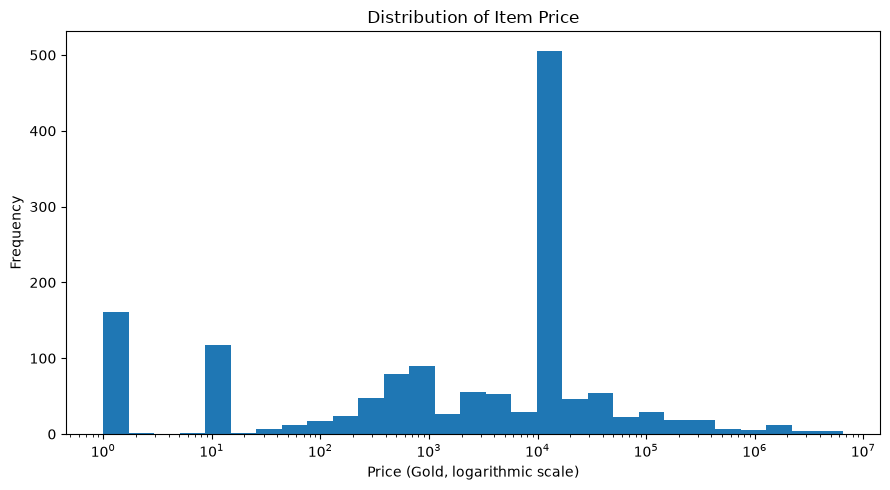

In [ ]:
# DISTRIBUTION OF ITEM PRICE

price = df["price"].dropna()
price = price[price > 0]

bins = np.logspace(
    np.log10(price.min()),
    np.log10(price.max()),
    30
)

plt.figure(figsize=(9, 5))

plt.hist(
    price,
    bins=bins
)

plt.xscale("log")

plt.xlabel("Price (Gold, logarithmic scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Item Price")

plt.tight_layout()
plt.show()

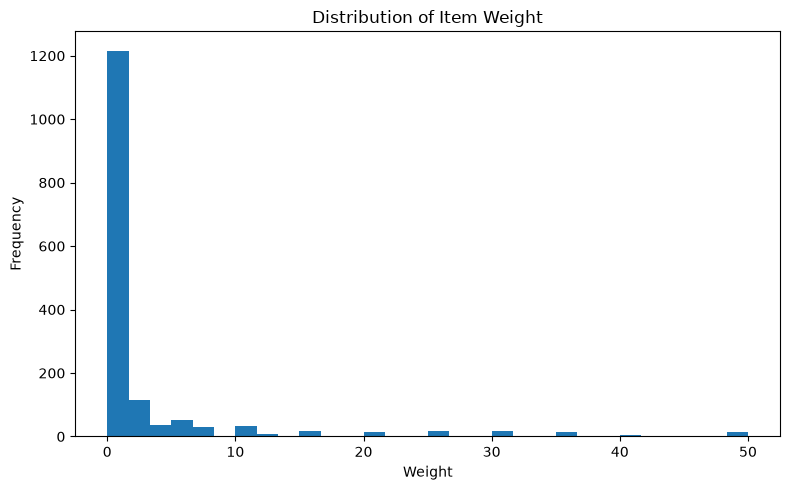

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["weight"].dropna(),
    bins=30
)

plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Distribution of Item Weight")

plt.tight_layout()
plt.show()

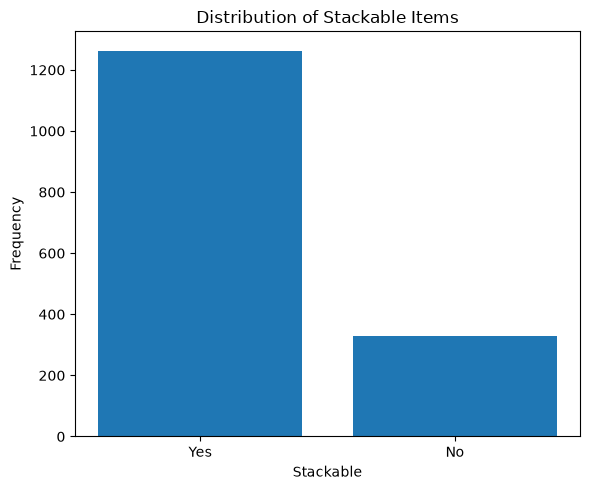

In [54]:
stackable_counts = (
    df["stackable"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

plt.bar(
    stackable_counts.index,
    stackable_counts.values
)

plt.xlabel("Stackable")
plt.ylabel("Frequency")
plt.title("Distribution of Stackable Items")

plt.tight_layout()
plt.show()

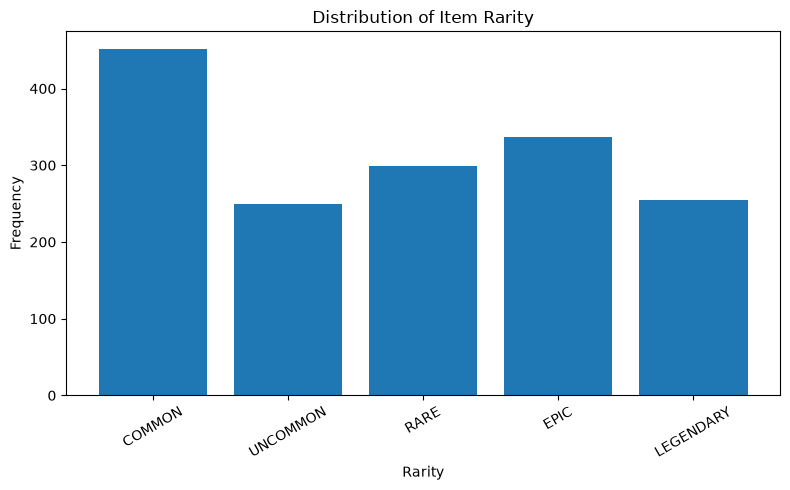

In [62]:
rarity_counts = (
    df["rarity"]
    .value_counts()
    .reindex(
        rarity_order,
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    rarity_counts.index,
    rarity_counts.values
)

plt.xlabel("Rarity")
plt.ylabel("Frequency")
plt.title("Distribution of Item Rarity")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

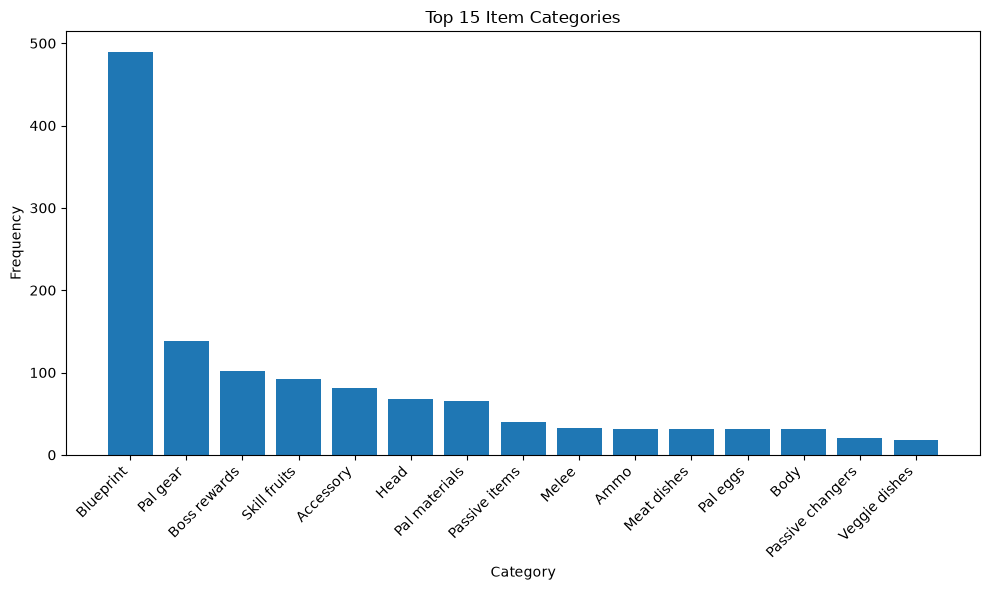

In [63]:
top_categories = (
    df["category"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_categories.index.astype(str),
    top_categories.values
)

plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title("Top 15 Item Categories")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### 6.1 Hubungan Price dan Weight

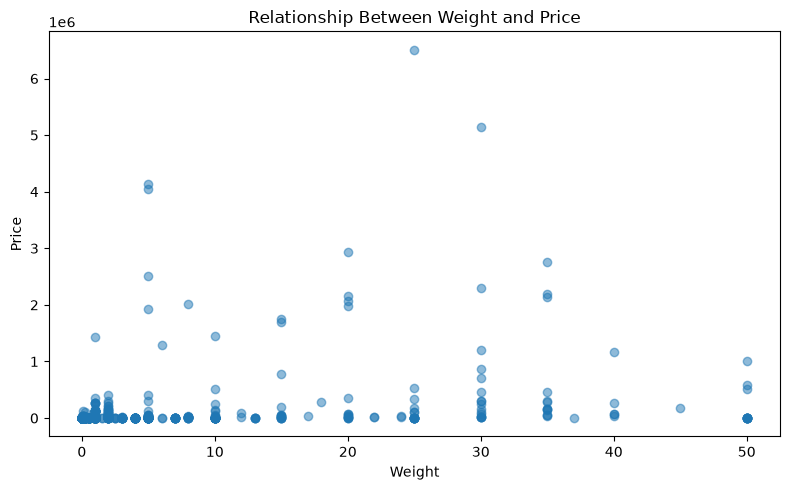

In [64]:
plot_df = df[
    ["price", "weight"]
].dropna()

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df["weight"],
    plot_df["price"],
    alpha=0.5
)

plt.xlabel("Weight")
plt.ylabel("Price")
plt.title("Relationship Between Weight and Price")

plt.tight_layout()
plt.show()

### 6.2 Distribusi Price Berdasarkan Rarity

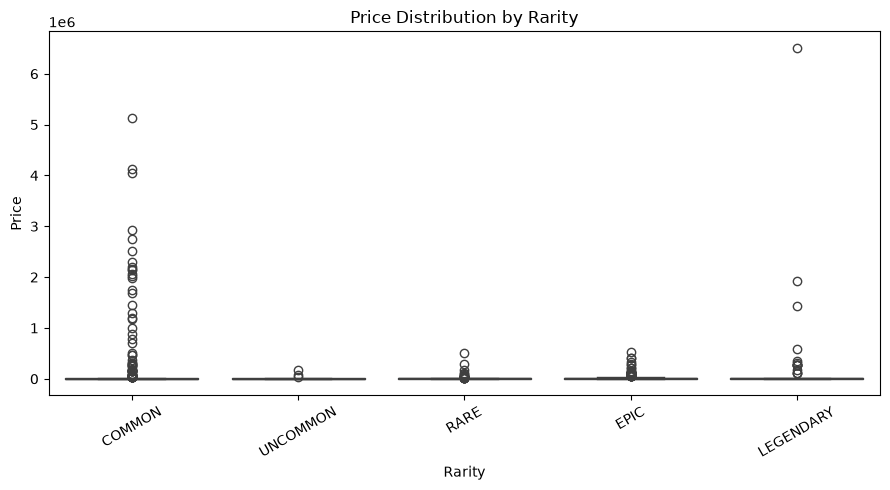

In [65]:
boxplot_df = df[
    ["rarity", "price"]
].dropna()

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=boxplot_df,
    x="rarity",
    y="price",
    order=rarity_order
)

plt.xlabel("Rarity")
plt.ylabel("Price")
plt.title("Price Distribution by Rarity")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

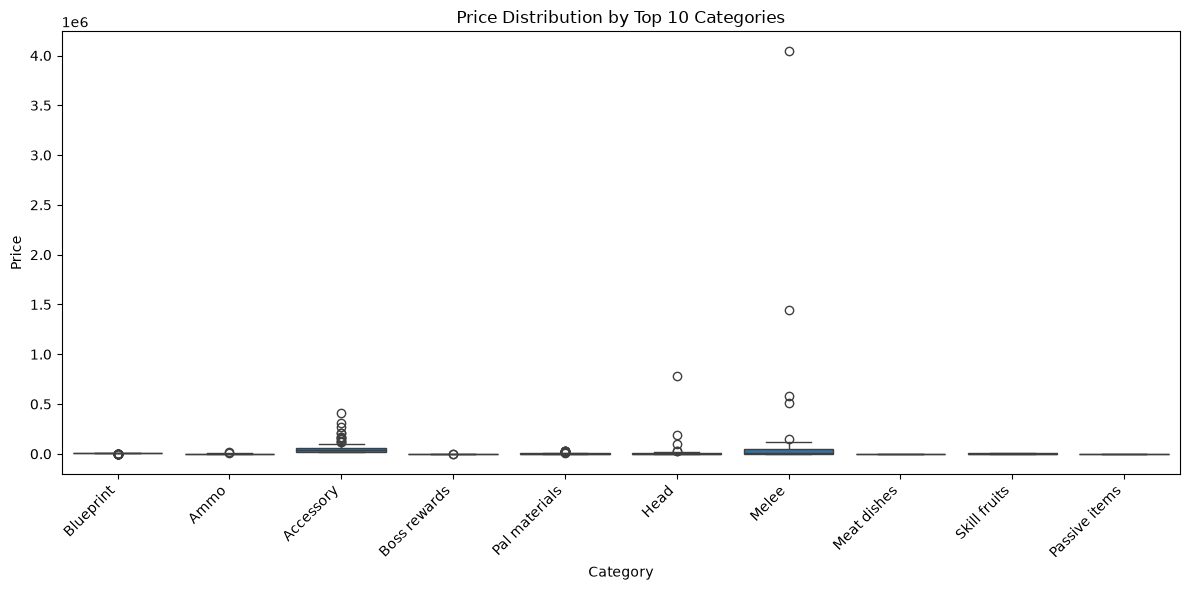

In [66]:
category_boxplot = df[
    ["category", "price"]
].dropna()

top_categories = (
    category_boxplot["category"]
    .value_counts()
    .head(10)
    .index
)

category_boxplot = category_boxplot[
    category_boxplot["category"]
    .isin(top_categories)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=category_boxplot,
    x="category",
    y="price"
)

plt.xlabel("Category")
plt.ylabel("Price")
plt.title(
    "Price Distribution by Top 10 Categories"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### 6.3 Correlation Heatmap

Correlation heatmap digunakan untuk melihat hubungan linear antara atribut numerik.

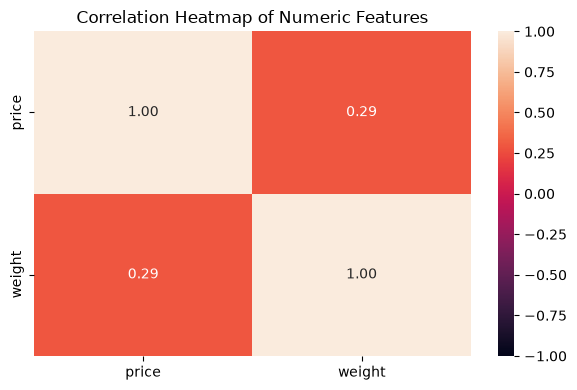

In [67]:
correlation_features = [
    "price",
    "weight"
]

corr_matrix = df[
    correlation_features
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Heatmap of Numeric Features"
)

plt.tight_layout()
plt.show()

## 7. Ringkasan Hasil EDA

Bagian ini merangkum karakteristik dataset berdasarkan hasil statistik, missing value, outlier, dan korelasi antaratribut numerik.

In [ ]:
# RINGKASAN HASIL EDA

print("===== DATASET =====")

print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print("\n===== FITUR UTAMA =====")

for feature in [
    "price",
    "weight",
    "stackable",
    "rarity",
    "category"
]:
    print("-", feature)

print("\n===== MISSING VALUE =====")

display(
    missing_summary
)

print("\n===== OUTLIER =====")

display(
    outlier_summary.round(2)
)

print("\n===== CORRELATION =====")

display(
    corr_matrix.round(3)
)

===== DATASET =====
Jumlah baris  : 1594
Jumlah kolom : 7

===== FITUR UTAMA =====
- price
- weight
- stackable
- rarity
- category

===== MISSING VALUE =====


,Missing Count,Missing Percentage (%)
price,143,8.97
weight,1,0.06
stackable,1,0.06
rarity,1,0.06
name,0,0.00
category,0,0.00
url,0,0.00



===== OUTLIER =====


,Atribut,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,price,290.0,10000.0,9710.0,-14275.0,24565.0,187,11.73
1,weight,0.0,1.0,1.0,-1.5,2.5,278,17.44



===== CORRELATION =====


,price,weight
price,1.000,0.291
weight,0.291,1.000


## 8. Kesimpulan

Berdasarkan hasil eksplorasi dataset item Palworld dari Paldex, dataset terdiri dari [jumlah observasi] observasi dan [jumlah atribut] atribut. Lima fitur utama yang dianalisis adalah price, weight, stackable, rarity, dan category.

Pada atribut numerik, price memiliki rata-rata sebesar [nilai] dan median sebesar [nilai], sedangkan weight memiliki rata-rata sebesar [nilai] dan median sebesar [nilai]. Distribusi price menunjukkan [insight berdasarkan histogram], sementara distribusi weight menunjukkan [insight].

Pada atribut kategorikal, kategori stackable yang paling banyak ditemukan adalah [kategori], rarity yang paling umum adalah [kategori], dan category yang memiliki jumlah item terbanyak adalah [kategori].

Analisis missing value menunjukkan bahwa [hasil analisis missing value]. Missing value pada atribut tertentu [jelaskan berdasarkan hasil yang diperoleh].

Berdasarkan metode IQR, ditemukan [jumlah] kandidat outlier pada price dan [jumlah] kandidat outlier pada weight. Nilai tersebut tidak langsung dihapus karena dapat merupakan observasi yang valid.

Dari visualisasi bivariat, hubungan antara price dan weight menunjukkan [hubungan berdasarkan scatter plot dan korelasi]. Boxplot berdasarkan rarity/category menunjukkan [insight utama].

Secara keseluruhan, EDA menunjukkan bahwa dataset memiliki variasi harga, berat, status stacking, rarity, dan kategori yang dapat digunakan untuk memahami karakteristik item Palworld.